____
# Test level of ggd noise after gaussian smoothing


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# To version for the stencil diff :
- from CLS mail : [1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280]
- from Dibarboure -> Arbic 2012 : 1/840 [-3, 32, -168, 672, 0, -672, 168, -32, 3]

-> nearly same distributions while differentiating BUT diffferent relation to white noise

In [2]:
def apply_stencil_diff_old(image, var, dx, dy):
    """
    Apply same stencil as CLS = Arbic 2012
    input : 
        image : 2D array, image swot
        var : str, must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'

        dx : float, x direction time step
        dy : float, y direction time step
    May be revised using Tranchant code : https://github.com/treden/SwotDiag/blob/main/SwotDiag/misc.py
    """
    from scipy.ndimage import convolve
    assert var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'], "var must be in 'dx', 'dy', 'dxx', 'dyy', 'dxy'"

    S = np.array([1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280])
    norm = -sum(np.arange(0, 9)*S)
    stx = np.array([S/norm])
    sty = stx.T
    print(norm)
    
    if var == 'dx' : output = convolve(image, stx, mode='mirror')/dx
    if var == 'dy' : output = convolve(image, sty, mode='mirror')/dy
    if var == 'dxx' : output = convolve(convolve(image, stx, mode='mirror'), stx)/dx/dx#/(norm**2)
    if var == 'dyy' : output = convolve(convolve(image, sty, mode='mirror'), sty)/dy/dy#/(norm**2)
    if var == 'dxy' : output = convolve(convolve(image, stx, mode='mirror'), sty)/dy/dx#/(norm**2)
    
    return xr.DataArray(output, dims=image.dims)


def apply_stencil_diff_new(image, var, dx, dy):
    """
    Apply same stencil as CLS = Arbic 2012
    input : 
        image : 2D array, image swot
        var : str, must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'

        dx : float, x direction time step
        dy : float, y direction time step
    May be revised using Tranchant code : https://github.com/treden/SwotDiag/blob/main/SwotDiag/misc.py
    """
    from scipy.ndimage import convolve
    assert var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'], "var must be in 'dx', 'dy', 'dxx', 'dyy', 'dxy'"

    S = -np.array([-3, 32, -168, 672, 0, -672, 168, -32, 3])#/840
    norm = -sum(np.arange(0, 9)*S)
    stx = np.array([S/norm])
    sty = stx.T
    print(norm)
    
    if var == 'dx' : output = convolve(image, stx, mode='mirror')/dx
    if var == 'dy' : output = convolve(image, sty, mode='mirror')/dy
    if var == 'dxx' : output = convolve(convolve(image, stx, mode='mirror'), stx)/dx/dx#/(norm**2)
    if var == 'dyy' : output = convolve(convolve(image, sty, mode='mirror'), sty)/dy/dy#/(norm**2)
    if var == 'dxy' : output = convolve(convolve(image, stx, mode='mirror'), sty)/dy/dx#/(norm**2)
    
    
    return xr.DataArray(output, dims=image.dims)

_______
# Compare stencil diff on SWOT

In [3]:
from swot import browse_swot_2km, add_grid_metrics
dfs = browse_swot_2km()
dss = xr.open_dataset(dfs.file.iloc[0])
dss = add_grid_metrics(dss)
dss['f'] = 2 * 2 * np.pi / 86164.1 * np.sin(dss.latitude * np.pi / 180)
dx = float(dss.dx.mean())
dy = float(dss.dy.mean())
g=9.81

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [4]:
dsold = apply_stencil_diff_old(dss.duacs_ssha_karin_2_filtered, 'dx', dx=dx, dy=dy)
dsnew = apply_stencil_diff_new(dss.duacs_ssha_karin_2_filtered, 'dx', dx=dx, dy=dy)
dsxarray = dss.duacs_ssha_karin_2_filtered.differentiate(coord='num_pixels')/dx

2.1999999999999997
-840


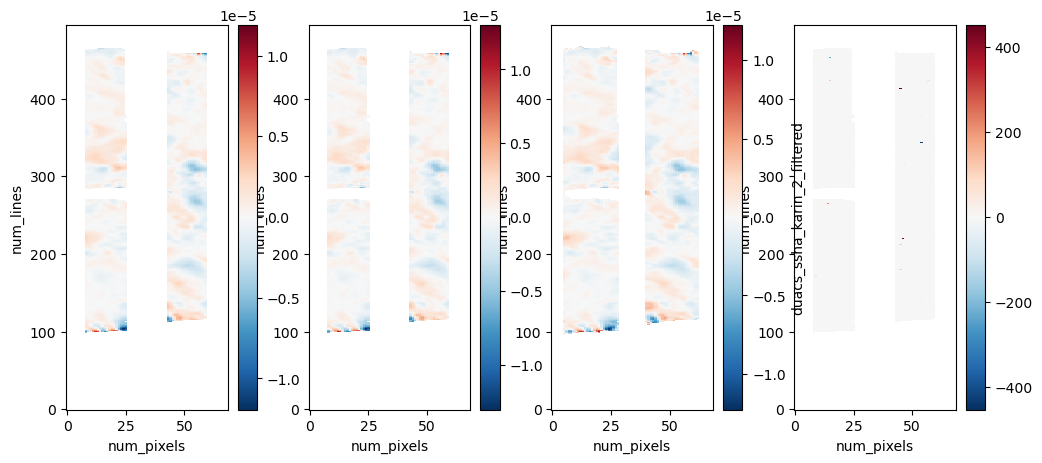

In [5]:
fig, axs = plt.subplots(1,4, figsize=(12, 5))
dsold.plot(ax=axs[0])
dsnew.plot(ax=axs[1])
dsxarray.plot(ax=axs[2])
#(dsnew-dsold).plot(ax=axs[2])
(dsnew/dsold).plot(ax=axs[3])

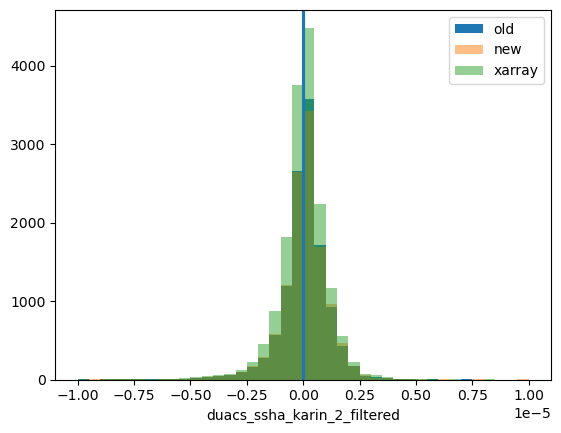

In [6]:
bins=np.arange(-1e-5, 1e-5, 5e-7)
(dsold).plot.hist(bins=bins, label='old')
(dsnew).plot.hist(bins=bins, alpha=0.5, label='new')
(dsxarray).plot.hist(bins=bins, alpha=0.5, label='xarray')

for ds in [dsold, dsnew, dsxarray] :
    plt.axvline(ds.mean().values)
plt.legend()

_______
# White noise STD

In [7]:
def E_ggd_from_noisemaps(dsn, cutoff, mask, dx, dy):
    from altimetry_filter import apply_gaussian_filter
    if cutoff==0:
        dsf = dsn.where(mask).rename('noise_ssh').to_dataset()
        for var in ['dx', 'dy'] : 
            dsf['g'+var] = 9.81*apply_stencil_diff_old(dsf.noise_ssh, var, dx=dx, dy=dy)
    else :
        dsf = apply_gaussian_filter(dsn, cutoff,  mask, dx, dy).where(mask).rename('noise_ssh').to_dataset()
        for var in ['dx', 'dy'] : 
            dsf['g'+var] = 9.81*apply_stencil_diff_old(dsf.noise_ssh, var, dx=dx, dy=dy)
    MS = (dsf.gdx**2).mean() + (dsf.gdy**2).mean()
    VAR = dsf.gdx.var() + dsf.gdy.var()
    return MS/U2, VAR/U2

def E_ggd_from_noisemaps_new(dsn, cutoff, mask, dx, dy):
    from altimetry_filter import apply_gaussian_filter
    if cutoff==0:
        dsf = dsn.where(mask).rename('noise_ssh').to_dataset()
        for var in ['dx', 'dy'] : 
            dsf['g'+var] = 9.81*apply_stencil_diff_new(dsf.noise_ssh, var, dx=dx, dy=dy)
    else :
        dsf = apply_gaussian_filter(dsn, cutoff,  mask, dx, dy).where(mask).rename('noise_ssh').to_dataset()
        for var in ['dx', 'dy'] : 
            dsf['g'+var] = 9.81*apply_stencil_diff_new(dsf.noise_ssh, var, dx=dx, dy=dy)
    MS = (dsf.gdx**2).mean() + (dsf.gdy**2).mean()
    VAR = dsf.gdx.var() + dsf.gdy.var()
    return MS/U2, VAR/U2
    

def generate_swot_noise(dss, sigma):
    noise = np.random.rand(dss.sizes['num_lines'],dss.sizes['num_pixels'])-0.5
    noise = sigma*noise/np.std(noise)
    dsn = xr.DataArray(noise, dict(num_lines=('num_lines', dss.num_lines.values), num_pixels=('num_pixels', dss.num_pixels.values)))
    return dsn.where(dss.duacs_editing_flag==0)

# Generate white noise on SWOT

In [8]:
sigmassh = 4e-3
from swot import browse_swot_2km, add_grid_metrics
dfs = browse_swot_2km()
dss = xr.open_dataset(dfs.file.iloc[0])
dss = add_grid_metrics(dss)
dx = float(dss.dx.mean())
dy = float(dss.dy.mean())

dsn = generate_swot_noise(dss, sigmassh)
mask = dss.duacs_editing_flag.where(dss.duacs_editing_flag!=0,1).where(dss.duacs_editing_flag==0,0)



/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


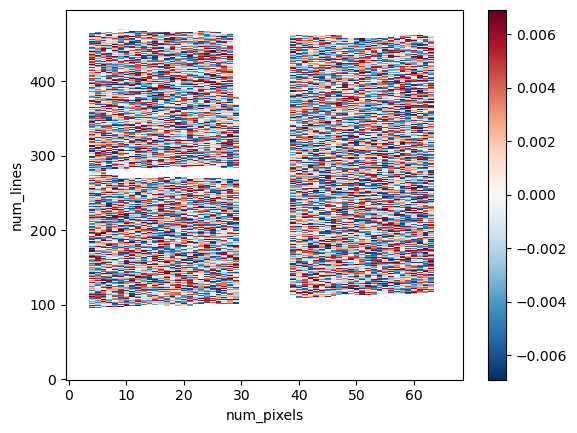

In [9]:
dsn.plot()

In [10]:
# loop
Sigmassh = np.arange(0, 10e-3, 3e-4)#m
cutoff = np.arange(0, 60e3, 5e2)
MS_old=[]
VAR_old=[]
for sigmassh in Sigmassh:
    dsn = generate_swot_noise(dss, sigmassh)
    ms_, var_ = E_ggd_from_noisemaps(dsn, 0, mask, dx, dy)
    MS_old.append(ms_.values)
    VAR_old.append(var_.values)


def func(sigma, a):
    return a*sigma**2
    
from scipy.optimize import curve_fit
popt, pcov = curve_fit(func, Sigmassh, MS_old)
ig = func(Sigmassh, *popt)


2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999999997
2.1999999999

In [11]:
# loop
MS_new=[]
VAR_new=[]
for sigmassh in Sigmassh:
    dsn = generate_swot_noise(dss, sigmassh)
    ms_, var_ = E_ggd_from_noisemaps_new(dsn, 0, mask, dx, dy)
    MS_new.append(ms_.values)
    VAR_new.append(var_.values)


def func(sigma, a):
    return a*sigma**2
    
from scipy.optimize import curve_fit
popt, pcov = curve_fit(func, Sigmassh, MS_new)
ig = func(Sigmassh, *popt)


-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840


In [12]:
def MSnoiseggd_from_sshnoisestd(sigmaN, d=2e3) : 
    """ 
    sigmaN : white noise std in m
    d : grid spacing in m
    """
    print('Caution : std must be given in m, E_ggd given in gamma^2')
    from cstes import U2
    g=9.81
    K = -sum(np.arange(0, 9)*[1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280])
    S2=(1/280)**2 + (4/105)**2+ (1/5)**2+(4/5)**2
    cste = 4*g**2/(K**2)/(d**2)
    
    return cste*S2*(sigmaN**2)/U2

def sshnoisestd_from_MSnoiseggd(E_ggd, d=2e3) : 
    """ 
    E_ggd : pressure gradient MS in gamma^2
    d : grid spacing in m
    """
    print('Caution : E_ggd must be given in gamma^2, std must return in m')
    from cstes import U2
    g=9.81
    K = -sum(np.arange(0, 9)*[1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280])
    S2=(1/280)**2 + (4/105)**2+ (1/5)**2+(4/5)**2
    
    return np.sqrt(E_ggd*U2*(K*d)**2/(4*g**2*S2))
    
E_ggd_old = MSnoiseggd_from_sshnoisestd(Sigmassh, d=2e3)
ss_old = sshnoisestd_from_MSnoiseggd(E_ggd_old)

Caution : std must be given in m, E_ggd given in gamma^2
Caution : E_ggd must be given in gamma^2, std must return in m


In [14]:
def E_GGD_from_whitenoise_sigmaSSH(sigssh, d=2e3) :
    """ 
    E_ggd : pressure gradient MS in gamma^2
    d : grid spacing in m
    """
    g=9.81
    K=840
    cste = 4*g**2/(K*d)**2
    S2 = (3**2)+(32**2)+(168**2)+(672**2)
    return cste*S2*(sigssh**2)/U2


def whitenoise_sigmaSSH_from_E_GGD(E_ggd, d=2e3) :
    """ 
    E_ggd : pressure gradient MS in gamma^2
    d : grid spacing in m
    """
    g=9.81
    K=840
    #cste = 4*g**2/(K*d)**2
    S2 = (3**2)+(32**2)+(168**2)+(672**2)
    return np.sqrt(E_ggd*U2*(K*d)**2/(4*g**2*S2))


E_ggd_new = E_GGD_from_whitenoise_sigmaSSH(Sigmassh, d=2e3)
ss_new = whitenoise_sigmaSSH_from_E_GGD(E_ggd_new)

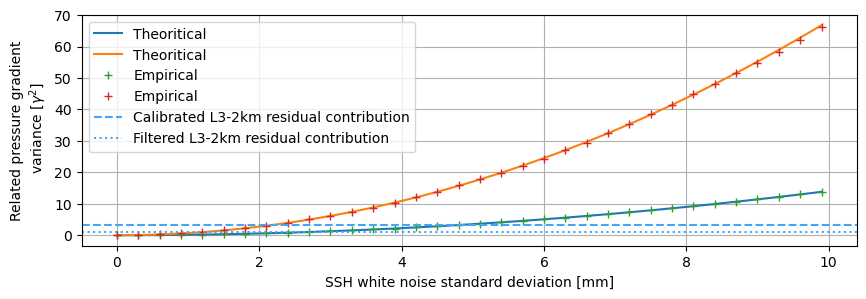

In [15]:
fig, ax = plt.subplots(1, 1, figsize = (10, 3),  frameon=False)
#ax.plot(Sigmassh, ig, label = 'Fit')
ax.plot(Sigmassh*1e3, E_ggd_old, label = 'Theoritical')
ax.plot(Sigmassh*1e3, E_ggd_new, label = 'Theoritical')
ax.plot(Sigmassh*1e3, np.array(MS_old), label = 'Empirical', ls='', marker='+')
ax.plot(Sigmassh*1e3, np.array(MS_new), label = 'Empirical', ls='', marker='+')
ax.axhline(3.1, label = 'Calibrated L3-2km residual contribution', color=c0['ggd'], ls='--')
ax.axhline(1.1, label = 'Filtered L3-2km residual contribution', color=c0['ggd'], ls=':')
ax.set_xlabel('SSH white noise standard deviation [mm]')
ax.set_ylabel('Related pressure gradient\n'+r' variance [$\gamma^2$]')
ax.grid()
ax.legend()

In [16]:
S = [1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280]
K = -sum(np.arange(0, 9)*S)
a=S/K
print(S/K)

[ 0.00162338 -0.01731602  0.09090909  0.36363636  0.         -0.36363636
 -0.09090909  0.01731602 -0.00162338]


In [17]:
S = [-3, 32, -168, 672, 0, -672, 168, -32, 3]
K = -sum(np.arange(0, 9)*S)
b=S/K
print(S/K)

[-0.00357143  0.03809524 -0.2         0.8         0.         -0.8
  0.2        -0.03809524  0.00357143]


In [18]:
a/b

/dev/shm/pbs.3761871.datarmor0/ipykernel_15036/1348051284.py:1: RuntimeWarning: invalid value encountered in divide
  a/b


array([-0.45454545, -0.45454545, -0.45454545,  0.45454545,         nan,
        0.45454545, -0.45454545, -0.45454545, -0.45454545])

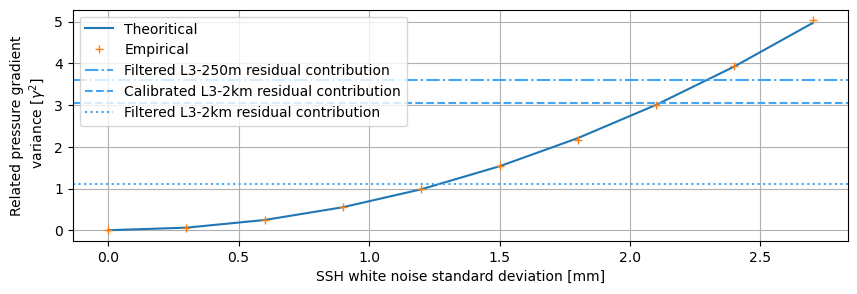

In [18]:
i=10
fig, ax = plt.subplots(1, 1, figsize = (10, 3),  frameon=False)
#ax.plot(Sigmassh, ig, label = 'Fit')
#ax.plot(Sigmassh*1e2, E_ggd_old, label = 'Theoritical')
ax.plot(Sigmassh[:i]*1e3, E_ggd_new[:i], label = 'Theoritical')
#ax.plot(Sigmassh*1e2, np.array(MS_old), label = 'Empirical', ls='', marker='+')
ax.plot(Sigmassh[:i]*1e3, np.array(MS_new[:i]), label = 'Empirical', ls='', marker='+')
ax.axhline(3.6, label = 'Filtered L3-250m residual contribution', color=c0['ggd'], ls='-.')
ax.axhline(3.05, label = 'Calibrated L3-2km residual contribution', color=c0['ggd'], ls='--')
ax.axhline(1.1, label = 'Filtered L3-2km residual contribution', color=c0['ggd'], ls=':')
ax.set_xlabel('SSH white noise standard deviation [mm]')
ax.set_ylabel('Related pressure gradient\n'+r' variance [$\gamma^2$]')
ax.grid()
ax.legend()

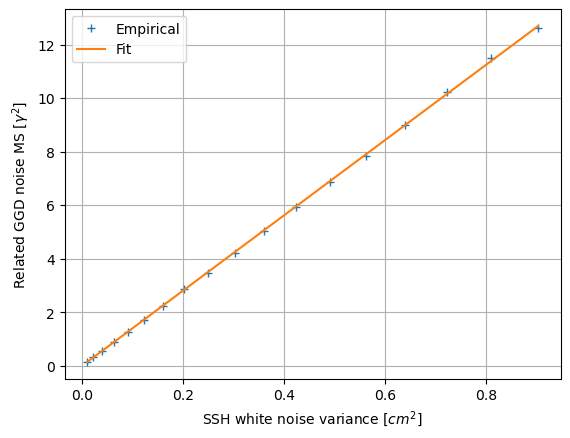

In [180]:
fig, ax = plt.subplots(1, 1, frameon=False)
ax.plot(Sigmassh**2/1e-4, MS, label = 'Empirical', ls='', marker='+')
ax.plot(Sigmassh**2/1e-4, ig, label = 'Fit')
ax.set_xlabel(r'SSH white noise variance [$cm^2$]')
ax.set_ylabel(r'Related GGD noise MS [$\gamma^2$]')
ax.grid()
ax.legend()

_______
# Gaussian filter

In [31]:
def noise_gaussian_MS():
    # swot image
    from swot import browse_swot_2km, add_grid_metrics
    dfs = browse_swot_2km()
    dss = xr.open_dataset(dfs.file.iloc[0])
    dss = add_grid_metrics(dss)
    dx = float(dss.dx.mean())
    dy = float(dss.dy.mean())

    mask = dss.duacs_editing_flag.where(dss.duacs_editing_flag!=0,1).where(dss.duacs_editing_flag==0,0)

    # loop
    Sigmassh = np.arange(10e-3, 40e-3, 5e-3)
    cutoff = np.arange(0, 60e3, 5e2)
    MS=[]
    VAR=[]
    for sigmassh in Sigmassh:
        dsn = generate_swot_noise(dss, sigmassh)
        ms=[]
        var=[]
        for ct in cutoff:
            ms_, var_ = E_ggd_from_noisemaps_new(dsn, ct, mask, dx, dy)
            ms.append(ms_.values)
            var.append(var_.values)
        print(len(ms))
        MS.append(xr.DataArray(ms, coords={'cutoff':('cutoff', cutoff)}))
        VAR.append(xr.DataArray(var, coords={'cutoff':('cutoff', cutoff)}))
    return xr.concat(MS, dim = pd.Index(Sigmassh, name = 'sigmassh'))

dsms = noise_gaussian_MS()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840
-840


In [32]:
dsms['sigmassh'] = np.round(dsms['sigmassh'],4).assign_attrs({'long_name':'SSH white noise standard deviation'})

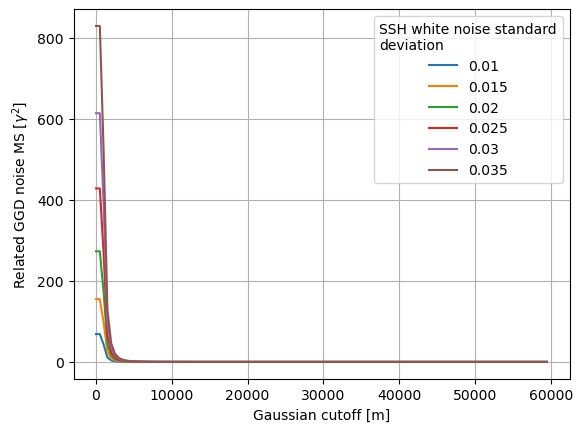

In [33]:
fig, ax = plt.subplots(1, 1, frameon=False)
dsms.rename('ms_noise_ggd').plot(hue='sigmassh', ax=ax)
#ax.set_xlabel('SSH white noise standard deviation [m]')
ax.set_ylabel(r'Related GGD noise MS [$\gamma^2$]')
ax.set_xlabel('Gaussian cutoff [m]')
ax.grid()

In [20]:
dsms.rename('ms_noise_ggd').to_netcdf(os.path.join(zarr_dir, 'diag_files', 'ms_noise_gaussian.nc'))